In [1]:
import numpy as np
from mpi4py import MPI
from dolfinx import mesh, geometry, fem
import ufl
import gmsh
from dolfinx.io import gmsh as gmshio
from dolfinx.fem.petsc import NonlinearProblem
from petsc4py import PETSc
import basix.ufl
import matplotlib.pyplot as plt
import pyvista as pv
import dolfinx.plot

In [2]:
def project_to_P1(domain, u):
    # Élément vectoriel P1 compatible avec ta version
    element_P1 = basix.ufl.element("Lagrange", domain.topology.cell_name(), 1, shape=(3,))
    V1 = fem.functionspace(domain, element_P1)
    u_P1 = fem.Function(V1)
    u_P1.interpolate(u)
    return u_P1

Geometry

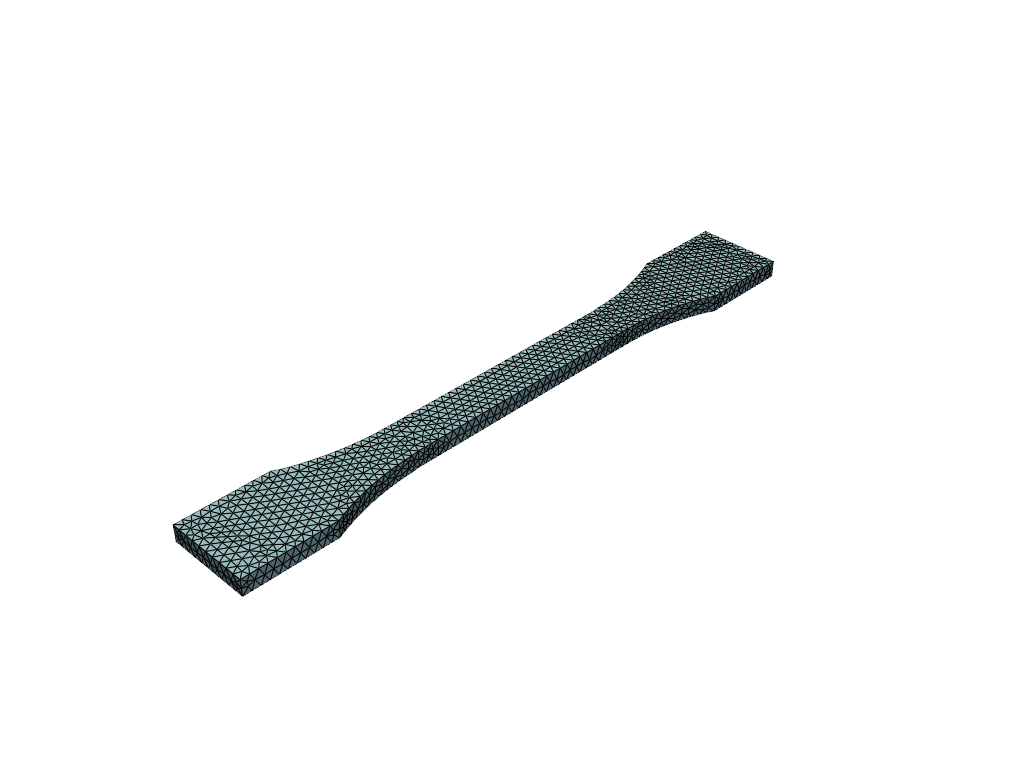

(<dolfinx.mesh.Mesh at 0x7cb60b8af620>,
 <dolfinx.mesh.MeshTags at 0x7cb60d9b0740>)

In [5]:
def create_geometry(h: float) -> tuple[mesh.Mesh, ufl.Measure]:

    gmsh.initialize()                                               
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("geometry_test")

    P1 = gmsh.model.geo.addPoint(0.0, 0.0, 0.0, h)
    P2 = gmsh.model.geo.addPoint(21.5, 0.0, 0.0, h)
    P3= gmsh.model.geo.addPoint(45.0, 5.0, 0.0, h)
    P4 = gmsh.model.geo.addPoint(50.0, 5.0, 0.0, h)
    P5 = gmsh.model.geo.addPoint(100.0, 5.0, 0.0, h)
    P6 = gmsh.model.geo.addPoint(105.0, 5.0, 0.0, h)
    P7 = gmsh.model.geo.addPoint(128.5, 0, 0.0, h)
    P8 = gmsh.model.geo.addPoint(150.0, 0, 0.0, h)
    P9= gmsh.model.geo.addPoint(150.0, 20.0, 0.0, h)
    P10= gmsh.model.geo.addPoint(128.5, 20.0, 0.0, h)
    P11= gmsh.model.geo.addPoint(105.0, 15.0, 0.0, h)
    P12 = gmsh.model.geo.addPoint(100.0, 15.0, 0.0, h)
    P13 = gmsh.model.geo.addPoint(50.0, 15.0, 0.0, h)
    P14 = gmsh.model.geo.addPoint(45.0, 15.0, 0.0, h)
    P15 = gmsh.model.geo.addPoint(21.5, 20.0, 0.0, h)
    P16 = gmsh.model.geo.addPoint(0.0, 20.0, 0.0, h)

    #center of circle
    P17 = gmsh.model.geo.addPoint(45.0,-55.0 , 0.0,h)
    P18 = gmsh.model.geo.addPoint(105.0, -55.0, 0.0,h)
    P19 = gmsh.model.geo.addPoint(105.0, 75.0, 0.0,h)
    P20 = gmsh.model.geo.addPoint(45.0, 75.0, 0.0,h)

    #external line
    l1 = gmsh.model.geo.addLine(P1, P2)
    l2 = gmsh.model.geo.addCircleArc(P2, P17, P3)
    l3 = gmsh.model.geo.addLine(P3, P4)
    l4 = gmsh.model.geo.addLine(P4, P5)
    l5 = gmsh.model.geo.addLine(P5, P6)
    l6 = gmsh.model.geo.addCircleArc(P6, P18, P7)
    l7 = gmsh.model.geo.addLine(P7, P8)
    l8 = gmsh.model.geo.addLine(P8, P9)
    l9 = gmsh.model.geo.addLine(P9, P10)
    l10 = gmsh.model.geo.addCircleArc(P10, P19, P11)
    l11 = gmsh.model.geo.addLine(P11, P12)
    l12 = gmsh.model.geo.addLine(P12, P13)
    l13 = gmsh.model.geo.addLine(P13, P14)
    l14 = gmsh.model.geo.addCircleArc(P14, P20, P15)
    l15 = gmsh.model.geo.addLine(P15, P16)
    l16 = gmsh.model.geo.addLine(P16, P1)

    # Inside line to divide the geometry
    lcut1 = gmsh.model.geo.addLine(P2, P15)
    lcut2 = gmsh.model.geo.addLine(P4, P13)
    lcut3 = gmsh.model.geo.addLine(P5, P12)
    lcut4 = gmsh.model.geo.addLine(P7, P10)

    gmsh.model.geo.synchronize()
    
    #creation of 5 different faces
    #left
    loop_left = gmsh.model.geo.addCurveLoop([l1, lcut1, l15, l16])
    surface_left = gmsh.model.geo.addPlaneSurface([loop_left])

    #left_transition
    loop_left_transition = gmsh.model.geo.addCurveLoop([l2, l3, lcut2, l13, l14,- lcut1])
    surface_left_transition = gmsh.model.geo.addPlaneSurface([loop_left_transition])

    #center
    loop_center = gmsh.model.geo.addCurveLoop([l4, lcut3, l12,- lcut2])
    surface_center = gmsh.model.geo.addPlaneSurface([loop_center])

    #right transition
    loop_right_transition = gmsh.model.geo.addCurveLoop([l5, l6, lcut4, l10, l11,- lcut3])
    surface_right_transition = gmsh.model.geo.addPlaneSurface([loop_right_transition])

    #right
    loop_right = gmsh.model.geo.addCurveLoop([l7, l8, l9,- lcut4])
    surface_right = gmsh.model.geo.addPlaneSurface([loop_right])

    #extrusion
    extruded_left = gmsh.model.geo.extrude([(2, surface_left)], 0, 0, 4)
    extruded_lef_transition = gmsh.model.geo.extrude([(2, surface_left_transition)], 0, 0, 4)
    extruded_center = gmsh.model.geo.extrude([(2, surface_center)], 0, 0, 4)
    extruded_right_transition = gmsh.model.geo.extrude([(2, surface_right_transition)], 0, 0, 4)
    extruded_right = gmsh.model.geo.extrude([(2, surface_right)], 0, 0, 4)

    gmsh.model.geo.synchronize()

    #set the size of the mesh
    gmsh.model.mesh.setSize(gmsh.model.getEntities(0), h)

    # Create the volume tag
    gmsh.model.addPhysicalGroup(3, [extruded_left[1][1]], 1)
    gmsh.model.addPhysicalGroup(3, [extruded_lef_transition[1][1]], 2)
    gmsh.model.addPhysicalGroup(3, [extruded_center[1][1]], 3)
    gmsh.model.addPhysicalGroup(3, [extruded_right_transition[1][1]], 4)
    gmsh.model.addPhysicalGroup(3, [extruded_right[1][1]], 5)

    #create face tag for the boundary
    #left
    top_surface_left = extruded_left[0][1]
    gmsh.model.addPhysicalGroup(2, [top_surface_left, surface_left],1000)

    #right
    top_surface_right = extruded_right[0][1]
    gmsh.model.addPhysicalGroup(2, [top_surface_right, surface_right],2000)

    gmsh.model.mesh.generate(3)

    data = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, 0, gdim=3)
    msh = data.mesh
    facet_tags = data.facet_tags


    msh.topology.create_connectivity(2, 3)
    msh.topology.create_connectivity(1, 2)
    msh.topology.create_connectivity(1, 3)

    topology, cell_types, geometry = dolfinx.plot.vtk_mesh(msh)
    pv.set_jupyter_backend("static")
    grid = pv.UnstructuredGrid(topology, cell_types, geometry)
    plotter = pv.Plotter()
    plotter.add_mesh(grid, show_edges=True)
    plotter.show()

    gmsh.finalize()
    return msh, facet_tags

Mooney-RIvlin with Piola-Kirchoff

In [1]:
from dolfinx import mesh, geometry, fem
from petsc4py import PETSc
from dolfinx import io

def evaluate_Moonley_Riv_Piola(msh: mesh.Mesh, facet_tags: mesh.MeshTags, k: int) -> float:
    domain = msh

    element_u = basix.ufl.element("Lagrange", domain.topology.cell_name(), k, shape=(3,))
    element_p = basix.ufl.element("Lagrange", domain.topology.cell_name(), k-1)
    mixed_el = basix.ufl.mixed_element([element_u, element_p])
    V = fem.functionspace(domain, mixed_el)

    V_u = V.sub(0)
    V_u0, _ = V_u.collapse()

    # BC 1 : u = 0 sur boundary_1
    boundary_1 = facet_tags.find(1000)
    dofs_1 = fem.locate_dofs_topological((V_u, V_u0), 2, boundary_1)
    u_D_1 = fem.Function(V_u0)
    u_D_1.x.array[:] = 0.0
    bc_1 = fem.dirichletbc(u_D_1, dofs_1, V_u)

    # BC 2 : déplacement imposé sur boundary_2 (incrémenté ensuite)
    boundary_2 = facet_tags.find(2000)
    dofs_2 = fem.locate_dofs_topological((V_u, V_u0), 2, boundary_2)
    u_D_2 = fem.Function(V_u0)
    u_D_2.x.array[:] = 0.0
    bc_2 = fem.dirichletbc(u_D_2, dofs_2, V_u)

    bcs = [bc_1, bc_2]

    def invariants(F):
        C = F.T * F
        I1 = ufl.tr(C)
        I2 = 0.5 * (ufl.tr(C)**2 - ufl.tr(C*C))
        return I1, I2

    def strain_energy_incompressible(F, C10, C01, C02):
        I1, I2 = invariants(F)
        W = C10 * (I1 - 3) + C01 * (I2 - 3) + C02 * (I2 - 3)**2
        return W

    def F_def(u):
        return ufl.Identity(3) + ufl.grad(u)

    C01 = 17.4
    C10 = -11.11
    C02 = 3.134

    up = fem.Function(V)
    vq = ufl.TestFunction(V)
    u, p = ufl.split(up)
    v, q = ufl.split(vq)
    
    F = F_def(u)
    J = ufl.det(F)
    w_iso = strain_energy_incompressible(F, C10, C01, C02)

    Pi = w_iso * ufl.dx + p * (J-1) * ufl.dx

    R_total = ufl.derivative(Pi,up,vq)
    J_total = ufl.derivative(R_total,up)

    linear_solver = "mumps"
    petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "l2",
    "snes_stol": 1e-10,
    "snes_atol": 1e-10,
    "snes_rtol": 1e-8,
    "ksp_type": "preonly",
    "pc_type": "lu",
    "snes_max_it": 1000,
    "pc_factor_mat_solver_type": linear_solver,
    "snes_monitor": None,}

    problem = NonlinearProblem(
        R_total, up,
        bcs=bcs,
        J=J_total,  
        petsc_options_prefix="nonlinear_",
        petsc_options=petsc_options)

    Def=3

    with io.XDMFFile(domain.comm, "hyperelasticity.xdmf", "w") as file:
        file.write_mesh(domain)

    steps = 70
    deformation_step = np.linspace(0, Def, steps)

    for i, t in enumerate(deformation_step):
        u_D_2.x.array[:] = 0.0
        u_D_2.x.array[0::3] = t
        u_D_2.x.scatter_forward()
        u_sol = problem.solve()
        u_fun = u_sol.sub(0).collapse()
        u_P1 = project_to_P1(domain, u_fun)
        file.write_function(u_P1, t)
        print(f"[Step {i+1}/{steps}]  t = {t:.4f} / Def = {Def}  ({100*t/Def:.1f}% )")
    return 

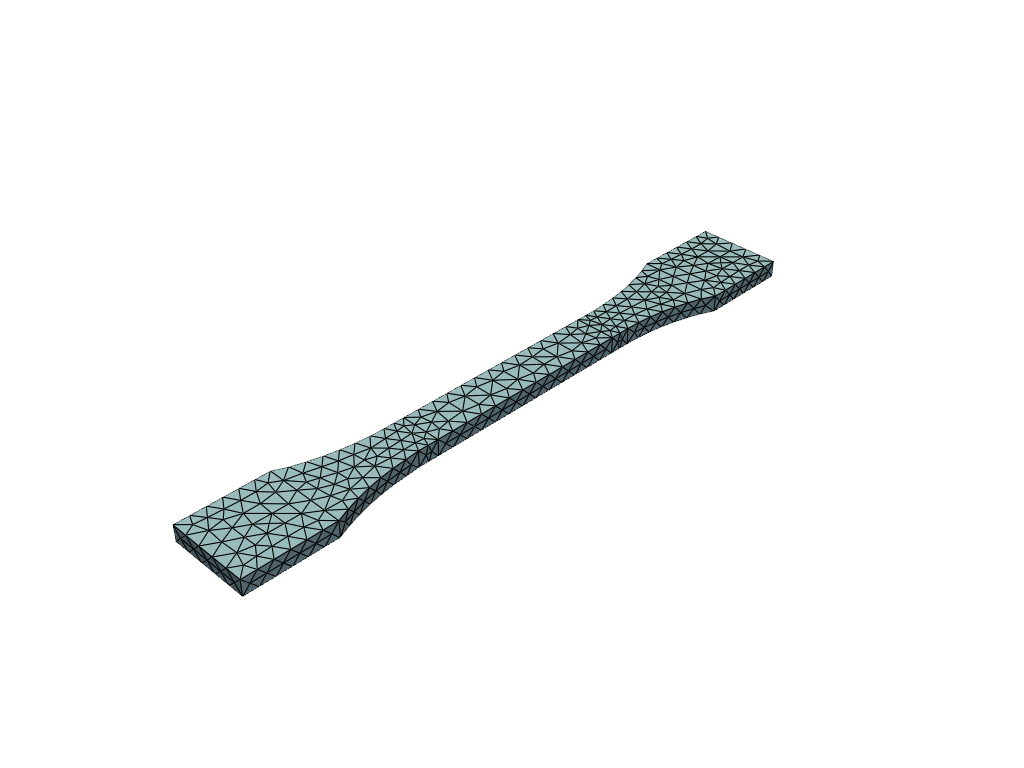

  0 SNES Function norm 4.995107317453e+03
  1 SNES Function norm 1.671769211105e-09
[Step 1/70]  t = 0.0000 / Def = 3  (0.0% )
  0 SNES Function norm 8.240468495837e+01
  1 SNES Function norm 1.046483117536e-03
  2 SNES Function norm 2.776411339693e-10
[Step 2/70]  t = 0.0435 / Def = 3  (1.4% )
  0 SNES Function norm 8.240394739129e+01
  1 SNES Function norm 1.043321039527e-03
  2 SNES Function norm 2.655069768203e-10
[Step 3/70]  t = 0.0870 / Def = 3  (2.9% )
  0 SNES Function norm 8.240321255963e+01
  1 SNES Function norm 1.040171445754e-03
  2 SNES Function norm 2.562523428655e-10
[Step 4/70]  t = 0.1304 / Def = 3  (4.3% )
  0 SNES Function norm 8.240248044542e+01
  1 SNES Function norm 1.037033907278e-03
  2 SNES Function norm 2.491030092466e-10
[Step 5/70]  t = 0.1739 / Def = 3  (5.8% )
  0 SNES Function norm 8.240175103173e+01
  1 SNES Function norm 1.033908082964e-03
  2 SNES Function norm 2.435699243471e-10
[Step 6/70]  t = 0.2174 / Def = 3  (7.2% )
  0 SNES Function norm 8.240

In [ ]:
msh, facet_tags = create_geometry(4)
evaluate_Moonley_Riv_Piola(msh, facet_tags, k=2)

Mooney-Rivlin with Cauchy

In [ ]:
from dolfinx import mesh, geometry, fem
from petsc4py import PETSc
from dolfinx import io

def evaluate_Moonley_Riv_Cauchy(msh: mesh.Mesh, facet_tags: mesh.MeshTags, k: int) -> float:
    domain = msh

    element_u = basix.ufl.element("Lagrange", domain.topology.cell_name(), k, shape=(3,))
    element_p = basix.ufl.element("Lagrange", domain.topology.cell_name(), k-1)
    mixed_el = basix.ufl.mixed_element([element_u, element_p])
    V = fem.functionspace(domain, mixed_el)

    V_u = V.sub(0)
    V_u0, _ = V_u.collapse()

    # BC 1 : u = 0 sur boundary_1
    boundary_1 = facet_tags.find(1000)
    dofs_1 = fem.locate_dofs_topological((V_u, V_u0), 2, boundary_1)
    u_D_1 = fem.Function(V_u0)
    u_D_1.x.array[:] = 0.0
    bc_1 = fem.dirichletbc(u_D_1, dofs_1, V_u)

    # BC 2 : déplacement imposé sur boundary_2 (incrémenté ensuite)
    boundary_2 = facet_tags.find(2000)
    dofs_2 = fem.locate_dofs_topological((V_u, V_u0), 2, boundary_2)
    u_D_2 = fem.Function(V_u0)
    u_D_2.x.array[:] = 0.0
    bc_2 = fem.dirichletbc(u_D_2, dofs_2, V_u)

    bcs = [bc_1, bc_2]

    def invariants(F):
        C = F.T * F
        I1 = ufl.tr(C)
        I2 = 0.5 * (ufl.tr(C)**2 - ufl.tr(C*C))
        return C, I1, I2

    def strain_energy_incompressible(F, C10, C01, C02):
        C, I1, I2 = invariants(F)
        W = C10 * (I1 - 3) + C01 * (I2 - 3) + C02 * (I2 - 3)**2
        return W

    def F_def(u):
        return ufl.Identity(3) + ufl.grad(u)

    C01 = 17.4
    C10 = -11.11
    C02 = 3.134

    up = fem.Function(V)
    vq = ufl.TestFunction(V)
    u, p = ufl.split(up)
    v, q = ufl.split(vq)

    F = F_def(u)
    J = ufl.det(F)
    C,I1,I2 = invariants(F)
    dI1df = 2*F
    dI2df = 2*(I1*F - F*C)

    P_iso = C10*dI1df + (C01 + 2*C02*(I2-3))*dI2df
    P_p = p * J * ufl.inv(F).T

    P = P_iso + P_p
    sigma = (1.0/J) * P * F.T

    R_u = ufl.inner(sigma, ufl.grad(v)) * ufl.dx
    R_p = q * (J - 1) * ufl.dx

    R_total = R_u + R_p
    J_total = ufl.derivative(R_total, up)

    linear_solver = "mumps"
    petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "l2",
    "snes_stol": 1e-10,
    "snes_atol": 1e-10,
    "snes_rtol": 1e-8,
    "ksp_type": "preonly",
    "pc_type": "lu",
    "snes_max_it": 1000,
    "pc_factor_mat_solver_type": linear_solver,
    "snes_monitor": None,}

    problem = NonlinearProblem(
        R_total, up,
        bcs=bcs,
        J=J_total,  
        petsc_options_prefix="nonlinear_",
        petsc_options=petsc_options)

    Def=3

    with io.XDMFFile(domain.comm, "hyperelasticity.xdmf", "w") as file:
        file.write_mesh(domain)

    steps = 70
    deformation_step = np.linspace(0, Def, steps)

    for i, t in enumerate(deformation_step):
        u_D_2.x.array[:] = 0.0
        u_D_2.x.array[0::3] = t
        u_D_2.x.scatter_forward()
        u_sol = problem.solve()
        u_fun = u_sol.sub(0).collapse()
        u_P1 = project_to_P1(domain, u_fun)
        file.write_function(u_P1, t)
        print(f"[Step {i+1}/{steps}]  t = {t:.4f} / Def = {Def}  ({100*t/Def:.1f}% )")
    return 

: 

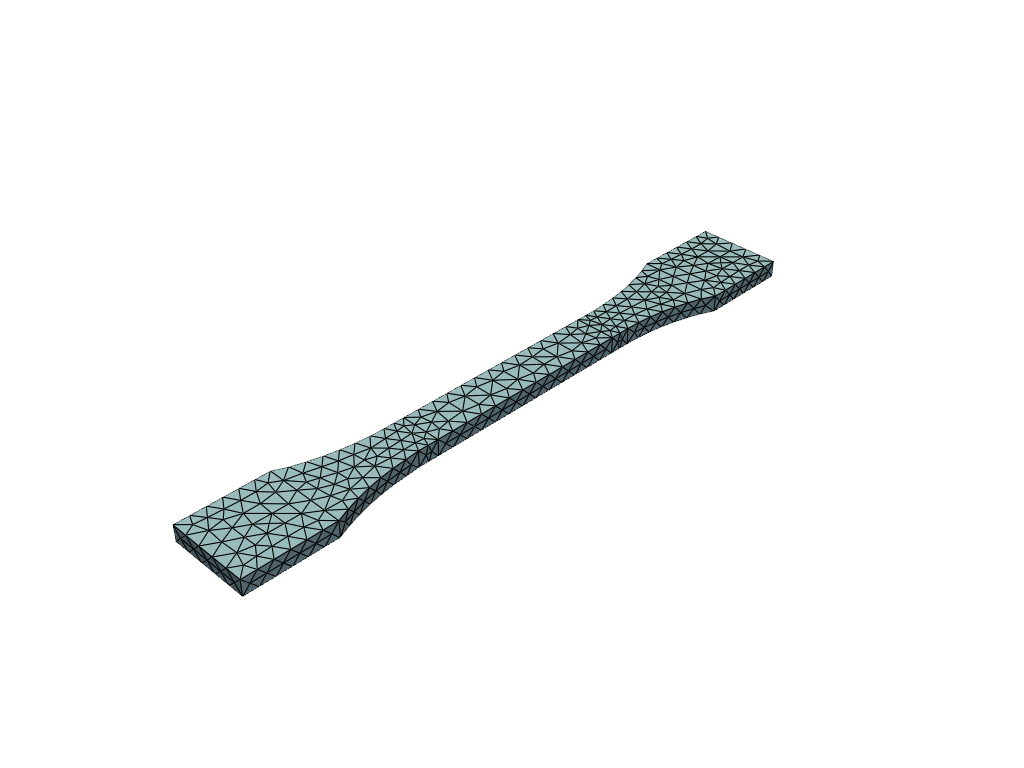

  0 SNES Function norm 4.995107317453e+03
  1 SNES Function norm 3.496628039945e-11
[Step 1/70]  t = 0.0000 / Def = 3  (0.0% )
  0 SNES Function norm 8.240468495838e+01
  1 SNES Function norm 9.726883134522e-04
  2 SNES Function norm 2.008239452993e-10
[Step 2/70]  t = 0.0435 / Def = 3  (1.4% )
  0 SNES Function norm 8.240467979283e+01


In [ ]:
msh, facet_tags = create_geometry(4)
evaluate_Moonley_Riv_Cauchy(msh, facet_tags, k=2)